# 6.5 Logistic Regression Basics

**Objective:** Binary Classification with Iris Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import os

# Use THIS notebook's folder paths
NOTEBOOK_DIR = os.getcwd()
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, 'datasets')
OUTPUTS_DIR = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"📁 Datasets: {DATASETS_DIR}")
print(f"📁 Outputs: {OUTPUTS_DIR}")

📁 Datasets: /home/z/my-project/ML-Labs-1-2-Final/02-Logistic-Regression/datasets
📁 Outputs: /home/z/my-project/ML-Labs-1-2-Final/02-Logistic-Regression/outputs


In [2]:
# Load Data - Binary Classification (Setosa vs Versicolor)
df = pd.read_csv(os.path.join(DATASETS_DIR, 'iris.csv'))
df_binary = df[df['species'].isin(['setosa', 'versicolor'])]

X = df_binary[['sepal_length', 'sepal_width']].values
y = (df_binary['species'] == 'versicolor').astype(int).values

print(f"Samples: {len(X)}")
print(f"Classes: Setosa (0), Versicolor (1)")

Samples: 100
Classes: Setosa (0), Versicolor (1)


In [3]:
# Train Model
model = LogisticRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")

Accuracy: 1.0000


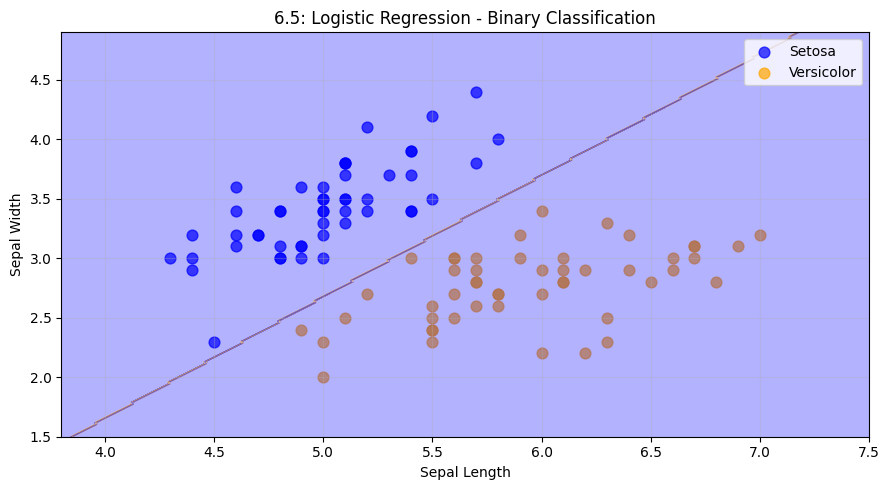

✅ Saved to: /home/z/my-project/ML-Labs-1-2-Final/02-Logistic-Regression/outputs/6.5_Logistic_Regression_Basics.png


In [4]:
# Decision Boundary - Save to outputs/
plt.figure(figsize=(9, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', alpha=0.7, s=60, label='Setosa')
plt.scatter(X[y==1, 0], X[y==1, 1], color='orange', alpha=0.7, s=60, label='Versicolor')

x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, colors=['blue', 'orange'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('6.5: Logistic Regression - Binary Classification')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '6.5_Logistic_Regression_Basics.png'), dpi=120)
plt.show()
print(f"✅ Saved to: {OUTPUTS_DIR}/6.5_Logistic_Regression_Basics.png")